# Vehicle Distance Detection — Training & Evaluation Pipeline

**Authors:** Hananeh Shabestani, Setayesh Zaheri Azam
**Supervisor:** Dr. Moharram Mansourizadeh (acknowledged for guidance and supervision)

---

## Overview

This notebook implements a complete audio-based vehicle distance detection system for pedestrian safety. It covers:

1. **Feature Extraction** — 132 acoustic features (MFCC, Delta, Delta2, Spectral features, Doppler)
2. **Model Training** — XGBoost, SVM, and PyTorch MLP classifiers (5 classes)
3. **Safety-Oriented Threshold Tuning** — Maximizing recall for the danger class (Class 1)
4. **Ablation Study** — Impact of Doppler features
5. **ROC Analysis** — Class 1 detection performance
6. **Learning Curve** — Effect of dataset size
7. **Comprehensive Model Comparison** — XGBoost vs SVM vs PyTorch
8. **File-Level Split (No Data Leakage)** — Realistic evaluation
9. **Event-Level Safety Evaluation** — Hybrid detection logic

## Class Definitions

| Class | Distance Range | Meaning |
|-------|---------------|---------|
| 0 | ~50m -> 20m | Far - Approaching |
| 1 | ~20m -> 0m | **DANGER zone** |
| 2 | 0m -> ~20m | Near - Receding |
| 3 | 20m -> 50m | Far - Receding |
| 4 | - | No vehicle (Safe) |

## Setup

Before running, update the path variables in each cell to point to your local data folder:

```python
DATA_FOLDER = r"/path/to/your/wav/files"
OUTPUT_CSV = r"./audio_features_dataset.csv"
```

> **Note:** The original notebook used Windows paths (`E:\123456`). Update these to match your environment.

In [2]:
import os
import re
import librosa
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# =========================
# تنظیمات
# =========================

DATA_FOLDER = r"E:\123456"
OUTPUT_CSV = r"E:\audio_features_dataset.csv"
SCALER_PATH = r"E:\audio_scaler.pkl"
META_PATH = r"E:\feature_metadata.pkl"

SR = 22050
N_MFCC = 20

# =========================
# استخراج لیبل از نام فایل
# فرمت:
# number_class یا number_class-extra
# مثال:
# 12_3.wav
# 8_1-4.wav
# =========================

def extract_label(filename):
    name = os.path.splitext(filename)[0]
    match = re.search(r"_(\d)", name)
    if match:
        return int(match.group(1))
    return None


# =========================
# استخراج ویژگی (بهینه‌تر)
# =========================

def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SR)

    if len(y) == 0:
        return None

    # نرمال‌سازی سریع‌تر
    max_val = np.max(np.abs(y))
    if max_val > 0:
        y = y / max_val

    y, _ = librosa.effects.trim(y, top_db=20)

    features = []

    # ---- MFCC + دلتا ----
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    for feat in (mfcc, delta, delta2):
        features.extend(np.mean(feat, axis=1))
        features.extend(np.std(feat, axis=1))

    # ---- Spectral Features (بهینه‌شده) ----
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]

    for feat in (centroid, bandwidth, rolloff, zcr, rms):
        features.append(np.mean(feat))
        features.append(np.std(feat))

    # ---- Doppler / رفتار طیفی ----
    slope = np.polyfit(range(len(centroid)), centroid, 1)[0]
    centroid_diff_std = np.std(np.diff(centroid))

    features.append(slope)
    features.append(centroid_diff_std)

    return np.array(features)


# =========================
# پردازش کل پوشه
# =========================

rows = []

files = [f for f in os.listdir(DATA_FOLDER) if f.endswith(".wav")]

for file in tqdm(files):
    label = extract_label(file)
    if label is None:
        continue

    path = os.path.join(DATA_FOLDER, file)
    feats = extract_features(path)

    if feats is None:
        continue

    row = {
        "filename": file,
        "label": label
    }

    for i, val in enumerate(feats):
        row[f"f_{i}"] = val

    rows.append(row)


# =========================
# ساخت دیتافریم
# =========================

df = pd.DataFrame(rows)

feature_cols = [col for col in df.columns if col.startswith("f_")]

X = df[feature_cols].values

# =========================
# Scaling (فقط یکبار)
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df[feature_cols] = X_scaled

# =========================
# ذخیره کامل روی درایو E
# =========================

df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
joblib.dump(scaler, SCALER_PATH)

# ذخیره اطلاعات متا برای آینده
metadata = {
    "sample_rate": SR,
    "n_mfcc": N_MFCC,
    "feature_count": len(feature_cols),
    "feature_columns": feature_cols
}

joblib.dump(metadata, META_PATH)

print("====================================")
print("Dataset saved to:", OUTPUT_CSV)
print("Scaler saved to:", SCALER_PATH)
print("Metadata saved to:", META_PATH)
print("Total samples:", len(df))
print("Total features:", len(feature_cols))
print("====================================")

  0%|                                                                                         | 0/6976 [00:00<?, ?it/s]C:\Users\fsaid\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████████████████████████████████████████████████████████████████████████| 6976/6976 [06:18<00:00, 18.45it/s]


Dataset saved to: E:\audio_features_dataset.csv
Scaler saved to: E:\audio_scaler.pkl
Metadata saved to: E:\feature_metadata.pkl
Total samples: 6967
Total features: 132


In [3]:
import pandas as pd

DATA_PATH = r"E:\audio_features_dataset.csv"

df = pd.read_csv(DATA_PATH)

class_counts = df["label"].value_counts().sort_index()
class_percent = df["label"].value_counts(normalize=True).sort_index() * 100

summary = pd.DataFrame({
    "count": class_counts,
    "percentage (%)": class_percent.round(2)
})

print(summary)


       count  percentage (%)
label                       
0       1156           16.59
1       1567           22.49
2       1255           18.01
3       1026           14.73
4       1963           28.18



Validation Accuracy: 0.8342898134863702

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.83      0.87       231
           1       0.77      0.86      0.81       314
           2       0.76      0.76      0.76       251
           3       0.84      0.74      0.79       205
           4       0.89      0.91      0.90       393

    accuracy                           0.83      1394
   macro avg       0.84      0.82      0.83      1394
weighted avg       0.84      0.83      0.83      1394



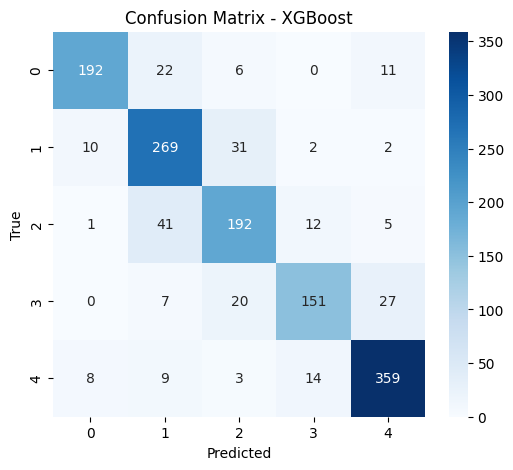

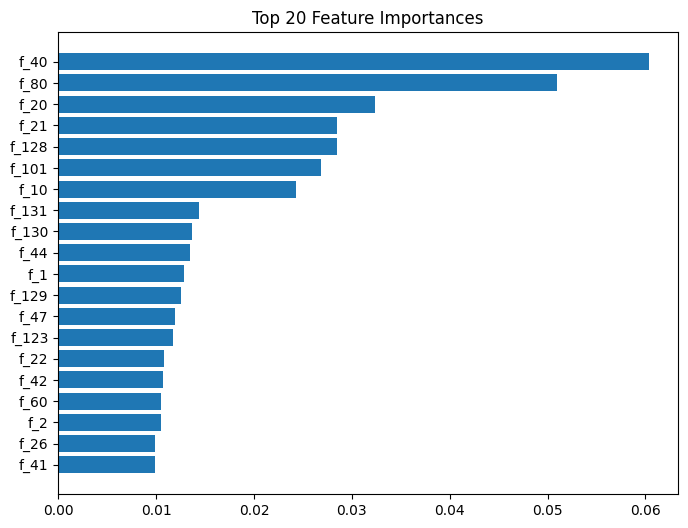


Model saved to: E:\xgboost_audio_model.pkl
Validation results saved to: E:\validation_results_xgboost.csv

[INFO] Results stored in 'main_model_results' variable for comparison.
      - Accuracy: 0.8342898134863702
      - Recall (Class 1): 0.856687898089172


In [7]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score,      # اضافه شده برای محاسبه ریکال
    precision_score    # اضافه شده برای محاسبه پرسیژن
)

from xgboost import XGBClassifier


# =====================================
# مسیرها
# =====================================

DATA_PATH = r"E:\audio_features_dataset.csv"
MODEL_PATH = r"E:\xgboost_audio_model.pkl"
RESULTS_PATH = r"E:\validation_results_xgboost.csv"


# =====================================
# خواندن دیتاست
# =====================================

df = pd.read_csv(DATA_PATH)

feature_cols = [col for col in df.columns if col.startswith("f_")]

X = df[feature_cols].values
y = df["label"].values


# =====================================
# Train / Validation Split
# =====================================

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# =====================================
# تعریف مدل XGBoost
# =====================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)


# =====================================
# آموزش
# =====================================

model.fit(X_train, y_train)


# =====================================
# ارزیابی و ذخیره در متغیرها
# =====================================

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val) # ذخیره احتمالات برای استفاده احتمالی بعدی

# محاسبه متریک‌ها برای ذخیره در متغیر
accuracy = accuracy_score(y_val, y_pred)
recall_c1 = recall_score(y_val, y_pred, labels=[1], average='macro')
precision_c1 = precision_score(y_val, y_pred, labels=[1], average='macro', zero_division=0)

# --- چاپ نتایج (همانند قبل) ---
print("\n================================")
print("Validation Accuracy:", accuracy)
print("================================\n")

print("Classification Report:\n")
print(classification_report(y_val, y_pred))


# =====================================
# Confusion Matrix
# =====================================

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - XGBoost")
plt.show()


# =====================================
# Feature Importance Plot
# =====================================

importances = model.feature_importances_
indices = np.argsort(importances)[-20:]  # 20 ویژگی مهم‌تر

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_cols[i] for i in indices])
plt.title("Top 20 Feature Importances")
plt.show()


# =====================================
# ذخیره نتایج validation در فایل (همانند قبل)
# =====================================

val_results = pd.DataFrame({
    "true_label": y_val,
    "predicted_label": y_pred
})

val_results.to_csv(RESULTS_PATH, index=False)


# =====================================
# ذخیره مدل (همانند قبل)
# =====================================

joblib.dump(model, MODEL_PATH)

print("\n================================")
print("Model saved to:", MODEL_PATH)
print("Validation results saved to:", RESULTS_PATH)
print("================================")


# ==========================================
# بخش جدید: ذخیره نتایج در متغیرها برای مقایسه بعدی
# ==========================================

main_model_results = {
    "model": model,
    "X_val": X_val,
    "y_val": y_val,
    "y_pred": y_pred,
    "y_proba": y_proba,
    "accuracy": accuracy,
    "recall_class_1": recall_c1,
    "precision_class_1": precision_c1,
    "feature_cols": feature_cols
}

print("\n[INFO] Results stored in 'main_model_results' variable for comparison.")
print(f"      - Accuracy: {accuracy}")
print(f"      - Recall (Class 1): {recall_c1}")


Starting Threshold Tuning for Class 1...

Threshold Tuning Results:
    Threshold  Recall_Class_1  Precision_Class_1  Accuracy
0        0.10           0.962              0.615     0.803
1        0.15           0.933              0.657     0.814
2        0.20           0.924              0.679     0.817
3        0.25           0.904              0.717     0.828
4        0.30           0.892              0.743     0.831
5        0.35           0.885              0.745     0.830
6        0.40           0.869              0.765     0.834
7        0.45           0.860              0.769     0.834
8        0.50           0.857              0.773     0.834
9        0.55           0.857              0.773     0.834
10       0.60           0.857              0.773     0.834
11       0.65           0.857              0.773     0.834
12       0.70           0.857              0.773     0.834
13       0.75           0.857              0.773     0.834
14       0.80           0.857              0.7

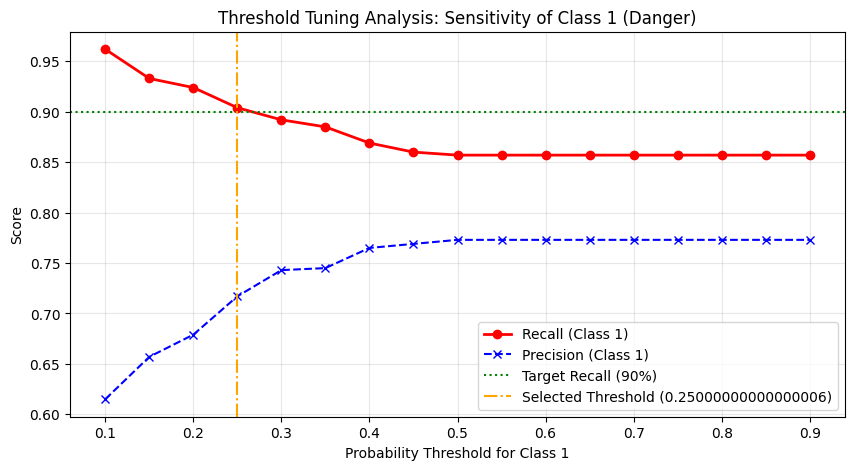

In [10]:
# ==========================================
# ادامه کد: Threshold Tuning برای کلاس ۱
# ==========================================

from sklearn.metrics import recall_score, precision_score, f1_score

# 1. دریافت احتمالات خروجی مدل (نه لیبل نهایی)
y_proba = model.predict_proba(X_val)

# 2. تعریف محدوده ترشهولد (از 0.1 تا 0.9)
# ما می‌خواهیم بررسی کنیم اگر به احتمال کلاس ۱ چقدر اعتماد کنیم.
thresholds = np.arange(0.1, 0.95, 0.05)

tuning_results = []
best_threshold = 0
best_recall = 0

print("\n========================================")
print("Starting Threshold Tuning for Class 1...")
print("========================================")

for t in thresholds:
    # کپی کردن پیش‌بینی پیش‌فرض (Argmax)
    y_pred_tuned = np.argmax(y_proba, axis=1)
    
    # منطق سفارشی:
    # هر جایی که احتمال کلاس ۱ بیشتر از ترشهولد (t) باشد، ما آن را به زور به کلاس ۱ اختصاص می‌دهیم.
    # حتی اگر احتمال کلاس دیگری کمی بیشتر باشد.
    mask_class_1 = y_proba[:, 1] > t
    y_pred_tuned[mask_class_1] = 1
    
    # محاسبه متریک‌ها
    rec_1 = recall_score(y_val, y_pred_tuned, labels=[1], average='macro')
    prec_1 = precision_score(y_val, y_pred_tuned, labels=[1], average='macro', zero_division=0)
    acc = accuracy_score(y_val, y_pred_tuned)
    
    tuning_results.append({
        "Threshold": round(t, 2),
        "Recall_Class_1": round(rec_1, 3),
        "Precision_Class_1": round(prec_1, 3),
        "Accuracy": round(acc, 3)
    })
    
    # پیدا کردن بهترین ترشهولد برای ریکال بالای ۹۰ (یا نزدیک‌ترین)
    if rec_1 >= 0.90:
        # اگر چندتا شد، اونی که پرسیژن بهتری داره رو انتخاب می‌کنیم (یا اولین کافی‌ست)
        best_threshold = t
        best_recall = rec_1

# اگر به ۹۰ نرسیدیم، بهترین حالت کلی رو برمی‌داریم
if best_threshold == 0:
    best_row = max(tuning_results, key=lambda x: x['Recall_Class_1'])
    best_threshold = best_row['Threshold']

# ==========================================
# نمایش نتایج به صورت جدول
# ==========================================
df_tuning = pd.DataFrame(tuning_results)
print("\nThreshold Tuning Results:")
print(df_tuning)

# ==========================================
# اعمال بهترین ترشهولد و مقایسه نهایی
# ==========================================

print(f"\nSelected Best Threshold for Class 1: {best_threshold}")

# اعمال نهایی
y_pred_final = np.argmax(y_proba, axis=1)
y_pred_final[y_proba[:, 1] > best_threshold] = 1

print("\n" + "="*30)
print("COMPARISON: Default vs Tuned")
print("="*30)

# نتایج پیش‌فرض
print("\n--- DEFAULT (Threshold 0.5 equivalent) ---")
print(classification_report(y_val, y_pred, digits=3))

# نتایج تیون شده
print("\n--- TUNED (Boosting Class 1) ---")
print(classification_report(y_val, y_pred_final, digits=3))


# ==========================================
# رسم نمودار تحلیل (برای مقاله)
# ==========================================

plt.figure(figsize=(10, 5))
plt.plot(df_tuning["Threshold"], df_tuning["Recall_Class_1"], marker='o', label='Recall (Class 1)', color='red', linewidth=2)
plt.plot(df_tuning["Threshold"], df_tuning["Precision_Class_1"], marker='x', label='Precision (Class 1)', color='blue', linestyle='--')
plt.axhline(y=0.9, color='green', linestyle=':', label='Target Recall (90%)')
plt.axvline(x=best_threshold, color='orange', linestyle='-.', label=f'Selected Threshold ({best_threshold})')

plt.title("Threshold Tuning Analysis: Sensitivity of Class 1 (Danger)")
plt.xlabel("Probability Threshold for Class 1")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



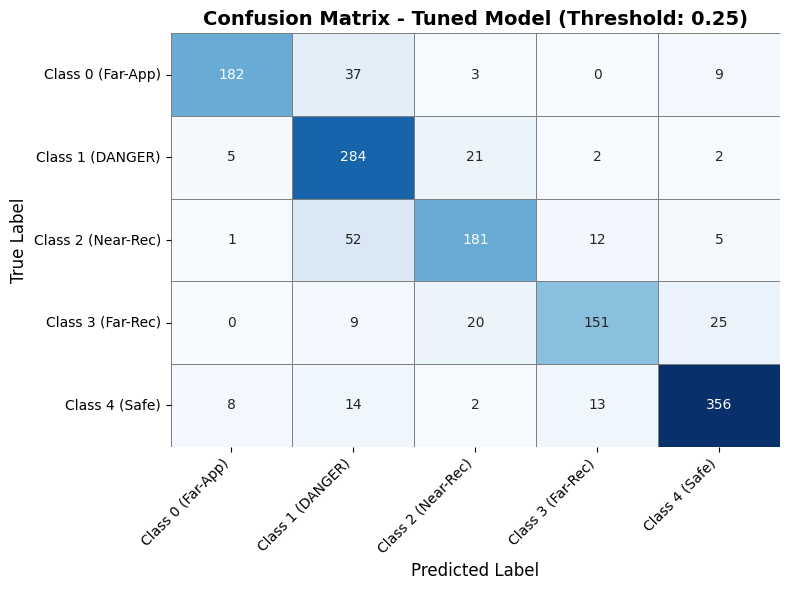

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# محاسبه ماتریس آشفتگی برای مدل تیون شده
# ==========================================

cm_tuned = confusion_matrix(y_val, y_pred_final)

class_names = [
    'Class 0 (Far-App)', 
    'Class 1 (DANGER)',  # کلاس مهم ما
    'Class 2 (Near-Rec)', 
    'Class 3 (Far-Rec)', 
    'Class 4 (Safe)'
]

# ==========================================
# رسم نمودار
# ==========================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_tuned, 
    annot=True,     
    fmt='d',         
    cmap='Blues',  
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor='gray'
)

plt.title(f'Confusion Matrix - Tuned Model (Threshold: {best_threshold:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [14]:
# ==========================================
# ذخیره مدل تیون شده XGBoost (بهgether با Threshold)
# ==========================================
import joblib

# بسته‌بندی مدل و آستانه در یک دیکشنری
xgb_tuned_package = {
    "model": model,             # مدل اصلی XGBoost
    "best_threshold": best_threshold,  # آستانه پیدا شده (مثلاً 0.25)
    "metadata": {
        "model_type": "XGBoost",
        "target_class": 1,
        "description": "Tuned for high recall on Class 1"
    }
}

# مسیر ذخیره
XGB_TUNED_PATH = r"E:\xgboost_tuned_model.pkl"

joblib.dump(xgb_tuned_package, XGB_TUNED_PATH)

print(f"✅ XGBoost Tuned Model saved to: {XGB_TUNED_PATH}")
print(f"   - Best Threshold saved: {best_threshold}")

✅ XGBoost Tuned Model saved to: E:\xgboost_tuned_model.pkl
   - Best Threshold saved: 0.25000000000000006


Preparing Reduced Dataset (Removing Doppler Features)...
Features removed for Ablation Study: ['f_130', 'f_131']

Training Reduced Model (XGBoost without Doppler)...
-> Reduced Model Accuracy: 0.8343
-> Reduced Model Recall (Class 1): 0.8662

Fetching results from Main Model (stored in memory)...


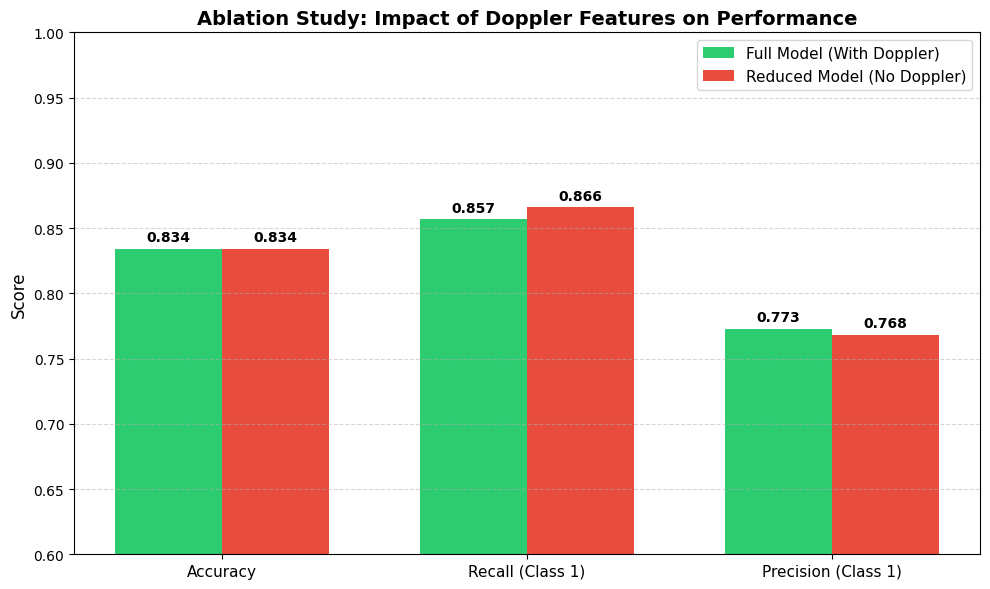


ANALYSIS SUMMARY:
Change in Recall (Class 1): -0.0096
>>> RESULT: No significant impact. Features might be redundant.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ==========================================
# ۱. آماده‌سازی داده‌های کاهش‌یافته (Matching Original Split)
# ==========================================

print("Preparing Reduced Dataset (Removing Doppler Features)...")

# خواندن دیتاست اصلی
df = pd.read_csv(DATA_PATH)

# تعریف نام ستون‌ها (همانند کد قبلی)
all_feature_cols = [col for col in df.columns if col.startswith("f_")]

# حذف دو ویژگی آخر (Slope و Std Diff که برای داپلر بودند)
# فرض بر این است که دو ستون آخر متعلق به ویژگی‌های داپلر هستند
reduced_feature_cols = all_feature_cols[:-2]
print(f"Features removed for Ablation Study: {all_feature_cols[-2:]}")

X_all = df[all_feature_cols].values
y = df["label"].values

# بسیار مهم: تقسیم داده باید دقیقاً همان باشد تا مقایسه منصفانه باشد
X_train_all, X_val_all, y_train, y_val = train_test_split(
    X_all, y, test_size=0.2, stratify=y, random_state=42
)

# ایجاد دیتای کاهش یافته (حذف ستون‌های آخر از Train و Val)
X_train_reduced = X_train_all[:, :-2]
X_val_reduced = X_val_all[:, :-2]

# استانداردسازی (باید جداگانه برای مدل جدید انجام شود)
scaler_reduced = StandardScaler()
X_train_reduced = scaler_reduced.fit_transform(X_train_reduced)
X_val_reduced = scaler_reduced.transform(X_val_reduced)


# ==========================================
# ۲. آموزش مدل کاهش‌یافته (Reduced Model)
# ==========================================

print("\nTraining Reduced Model (XGBoost without Doppler)...")

model_reduced = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

model_reduced.fit(X_train_reduced, y_train)
y_pred_reduced = model_reduced.predict(X_val_reduced)


# ==========================================
# ۳. محاسبه متریک‌های مدل جدید
# ==========================================

acc_reduced = accuracy_score(y_val, y_pred_reduced)
rec_reduced = recall_score(y_val, y_pred_reduced, labels=[1], average='macro')
prec_reduced = precision_score(y_val, y_pred_reduced, labels=[1], average='macro', zero_division=0)

print(f"-> Reduced Model Accuracy: {acc_reduced:.4f}")
print(f"-> Reduced Model Recall (Class 1): {rec_reduced:.4f}")


# ==========================================
# ۴. بازیابی نتایج مدل اصلی از متغیر ذخیره شده
# ==========================================

print("\nFetching results from Main Model (stored in memory)...")
acc_full = main_model_results['accuracy']
rec_full = main_model_results['recall_class_1']
prec_full = main_model_results['precision_class_1']


# ==========================================
# ۵. رسم نمودار مقایسه‌ای (Ablation Study)
# ==========================================

metrics = ['Accuracy', 'Recall (Class 1)', 'Precision (Class 1)']
full_scores = [acc_full, rec_full, prec_full]
reduced_scores = [acc_reduced, rec_reduced, prec_reduced]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# رسم ستون‌ها
bars1 = ax.bar(x - width/2, full_scores, width, label='Full Model (With Doppler)', color='#2ecc71') # سبز
bars2 = ax.bar(x + width/2, reduced_scores, width, label='Reduced Model (No Doppler)', color='#e74c3c') # قرمز

# افزودن اعداد روی ستون‌ها
ax.bar_label(bars1, padding=3, fmt='%.3f', fontsize=10, fontweight='bold')
ax.bar_label(bars2, padding=3, fmt='%.3f', fontsize=10, fontweight='bold')

# تنظیمات نمودار
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Ablation Study: Impact of Doppler Features on Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim([0.6, 1.0]) # زوم روی محور Y برای دیدن بهتر تفاوت‌ها
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# چاپ تحلیل متنی
# ==========================================
print("\n" + "="*60)
print("ANALYSIS SUMMARY:")
print("="*60)
drop_in_recall = rec_full - rec_reduced
print(f"Change in Recall (Class 1): {drop_in_recall:.4f}")
if drop_in_recall > 0.05:
    print(">>> RESULT: Significant drop in safety recall detected.")
    print(">>> This proves that the Doppler features are CRITICAL for detecting danger.")
elif drop_in_recall > 0.01:
    print(">>> RESULT: Minor drop in recall. Doppler features are helpful but not critical.")
else:
    print(">>> RESULT: No significant impact. Features might be redundant.")
print("="*60)

AUC Score (Class 1): 0.9686


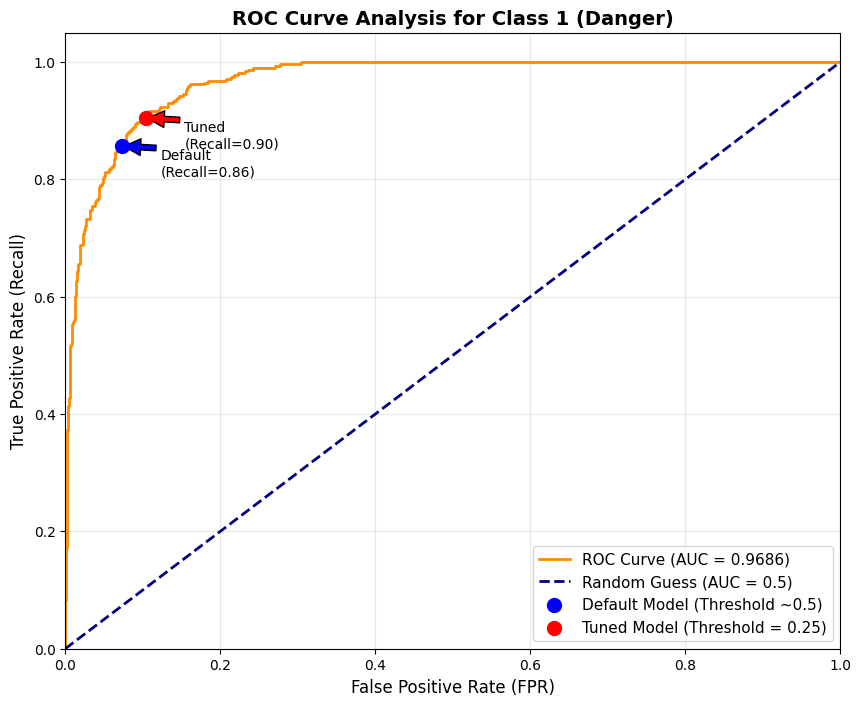


ROC Analysis Complete:
Default Model -> Recall: 0.8567, FPR: 0.0731
Tuned Model  -> Recall: 0.9045, FPR: 0.1037
Notice how the Tuned Model moved 'Up and Right' on the curve,
maximizing Safety (Recall) at the cost of more False Alarms (FPR).


In [13]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# ۱. دریافت داده‌ها از متغیرهای ذخیره شده
# ==========================================

# برچسب‌های واقعی (برای کلاس ۱ باید باینری شود: 1 یا 0)
y_true = main_model_results['y_val']
y_true_binary = (y_true == 1).astype(int) # 1 اگر کلاس ۱ بود، 0 در غیر این صورت

# احتمالات خروجی مدل برای کلاس ۱ (Predict Proba)
y_score = main_model_results['y_proba'][:, 1]

# ==========================================
# ۲. محاسبه منحنی ROC و AUC
# ==========================================

fpr, tpr, thresholds = roc_curve(y_true_binary, y_score)
roc_auc = auc(fpr, tpr)

print(f"AUC Score (Class 1): {roc_auc:.4f}")


# ==========================================
# ۳. محاسبه نقطه عملکرد پیش‌فرض (Default)
# ==========================================

# پیش‌بینی‌های پیش‌فرض مدل (بدون تیونینگ)
y_pred_default = main_model_results['y_pred']
y_pred_default_binary = (y_pred_default == 1).astype(int)

# محاسبه TPR و FPR برای پیش‌فرض
tp_default = np.sum((y_true_binary == 1) & (y_pred_default_binary == 1))
fp_default = np.sum((y_true_binary == 0) & (y_pred_default_binary == 1))
tn_default = np.sum((y_true_binary == 0) & (y_pred_default_binary == 0))
fn_default = np.sum((y_true_binary == 1) & (y_pred_default_binary == 0))

tpr_default_point = tp_default / (tp_default + fn_default)
fpr_default_point = fp_default / (fp_default + tn_default)


# ==========================================
# ۴. محاسبه نقطه عملکرد تیون شده (Tuned - Threshold 0.25)
# ==========================================

# بهترین ترشهولدی که در مرحله قبل پیدا کردیم
threshold_tuned = 0.25 
y_pred_tuned_binary = (y_score > threshold_tuned).astype(int)

# محاسبه TPR و FPR برای تیون شده
tp_tuned = np.sum((y_true_binary == 1) & (y_pred_tuned_binary == 1))
fp_tuned = np.sum((y_true_binary == 0) & (y_pred_tuned_binary == 1))
tn_tuned = np.sum((y_true_binary == 0) & (y_pred_tuned_binary == 0))
fn_tuned = np.sum((y_true_binary == 1) & (y_pred_tuned_binary == 0))

tpr_tuned_point = tp_tuned / (tp_tuned + fn_tuned)
fpr_tuned_point = fp_tuned / (fp_tuned + tn_tuned)


# ==========================================
# ۵. رسم نمودار ROC با دو نقطه مقایسه‌ای
# ==========================================

plt.figure(figsize=(10, 8))

# رسم منحنی اصلی
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')

# رسم خط تصادفی (Random Guess)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')

# رسم نقطه پیش‌فرض (آبی)
plt.scatter(fpr_default_point, tpr_default_point, color='blue', s=100, zorder=5, label='Default Model (Threshold ~0.5)')

# رسم نقطه تیون شده (قرمز)
plt.scatter(fpr_tuned_point, tpr_tuned_point, color='red', s=100, zorder=5, label=f'Tuned Model (Threshold = {threshold_tuned})')

# محدوده نمایش
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve Analysis for Class 1 (Danger)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# اضافه کردن متن اضافی روی نقاط
plt.annotate(f'Default\n(Recall={tpr_default_point:.2f})', 
             (fpr_default_point, tpr_default_point), 
             xytext=(fpr_default_point+0.05, tpr_default_point-0.05),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.annotate(f'Tuned\n(Recall={tpr_tuned_point:.2f})', 
             (fpr_tuned_point, tpr_tuned_point), 
             xytext=(fpr_tuned_point+0.05, tpr_tuned_point-0.05),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()

print("\n" + "="*60)
print("ROC Analysis Complete:")
print("="*60)
print(f"Default Model -> Recall: {tpr_default_point:.4f}, FPR: {fpr_default_point:.4f}")
print(f"Tuned Model  -> Recall: {tpr_tuned_point:.4f}, FPR: {fpr_tuned_point:.4f}")
print("Notice how the Tuned Model moved 'Up and Right' on the curve,")
print("maximizing Safety (Recall) at the cost of more False Alarms (FPR).")
print("="*60)

Loading dataset and preparing splits...
Starting Learning Curve Analysis...
This will take a few minutes as it trains 10 models...

Trained on  10.0% ( 557 samples) -> Acc: 0.7834 | Rec (Class 1): 0.7930
Trained on  20.0% (1114 samples) -> Acc: 0.7984 | Rec (Class 1): 0.8248
Trained on  30.0% (1671 samples) -> Acc: 0.8214 | Rec (Class 1): 0.8439
Trained on  40.0% (2229 samples) -> Acc: 0.8121 | Rec (Class 1): 0.8503
Trained on  50.0% (2786 samples) -> Acc: 0.8199 | Rec (Class 1): 0.8694
Trained on  60.0% (3343 samples) -> Acc: 0.8242 | Rec (Class 1): 0.8535
Trained on  70.0% (3901 samples) -> Acc: 0.8379 | Rec (Class 1): 0.8694
Trained on  80.0% (4458 samples) -> Acc: 0.8286 | Rec (Class 1): 0.8790
Trained on  90.0% (5015 samples) -> Acc: 0.8336 | Rec (Class 1): 0.8599
Trained on 100.0% (5573 samples) -> Acc: 0.8343 | Rec (Class 1): 0.8567

Learning Curve Results (Numerical):
 Data_Percent  Sample_Count  Accuracy  Recall_Class_1
         10.0           557  0.783357        0.792994
   

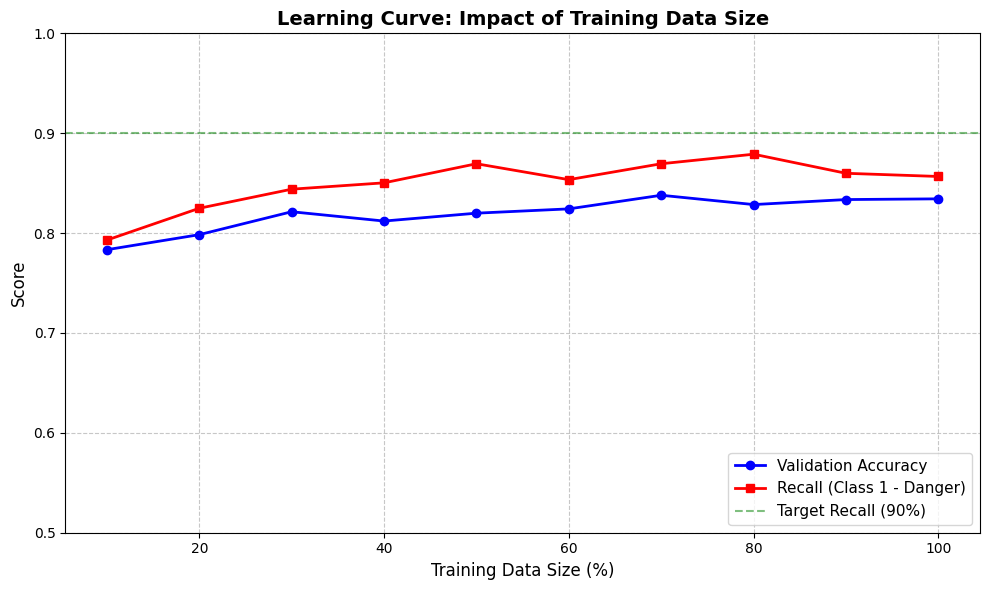


ANALYSIS:
Final Accuracy (100% data): 0.8343
Accuracy at 50% data:      0.8199
Difference:                0.0143
>>> RESULT: Moderate improvement observed.
>>> More data helped, but the model showed steady learning.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# ==========================================
# ۱. آماده‌سازی داده (بارگذاری و تقسیم)
# ==========================================

print("Loading dataset and preparing splits...")
df = pd.read_csv(DATA_PATH)

feature_cols = [col for col in df.columns if col.startswith("f_")]
X = df[feature_cols].values
y = df["label"].values

# تقسیم داده‌ها (Train/Test) - دقیقاً همان کاری که قبل کردیم
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# نسبت‌های داده برای آموزش (۱۰٪ تا ۱۰۰٪)
train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

results = []

print("Starting Learning Curve Analysis...")
print("This will take a few minutes as it trains 10 models...\n")

# ==========================================
# ۲. حلقه آموزش روی بخش‌های مختلف داده
# ==========================================

for frac in train_sizes:
    # محاسبه تعداد نمونه برای این درصد
    limit = int(len(X_train_full) * frac)
    
    # برش داده‌های آموزش (از ابتدا تا حد نصاب)
    X_train_sub = X_train_full[:limit]
    y_train_sub = y_train_full[:limit]
    
    # استانداردسازی (مهم: اسکیلر باید فقط روی همون بخش کوچک فیت شود)
    scaler = StandardScaler()
    X_train_sub_scaled = scaler.fit_transform(X_train_sub)
    X_val_scaled = scaler.transform(X_val) # داده تست را با همین اسکیلر تبدیل می‌کنیم
    
    # تعریف و آموزش مدل (هایپرپارامترهای ثابت)
    model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=5,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_sub_scaled, y_train_sub)
    y_pred = model.predict(X_val_scaled)
    
    # محاسبه متریک‌ها
    acc = accuracy_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred, labels=[1], average='macro')
    
    results.append({
        "Data_Percent": frac * 100,
        "Sample_Count": limit,
        "Accuracy": acc,
        "Recall_Class_1": rec
    })
    
    print(f"Trained on {frac*100:5.1f}% ({limit:4d} samples) -> Acc: {acc:.4f} | Rec (Class 1): {rec:.4f}")


# ==========================================
# ۳. نمایش نتایج عددی
# ==========================================

df_results = pd.DataFrame(results)
print("\n" + "="*50)
print("Learning Curve Results (Numerical):")
print("="*50)
print(df_results.to_string(index=False))


# ==========================================
# ۴. رسم نمودار منحنی یادگیری
# ==========================================

plt.figure(figsize=(10, 6))

# رسم دقت
plt.plot(df_results["Data_Percent"], df_results["Accuracy"], 
         marker='o', linestyle='-', color='blue', label='Validation Accuracy', linewidth=2)

# رسم ریکال کلاس ۱
plt.plot(df_results["Data_Percent"], df_results["Recall_Class_1"], 
         marker='s', linestyle='-', color='red', label='Recall (Class 1 - Danger)', linewidth=2)

# ناحیه هدف (مثلاً اگر هدف ریکال ۹۰ بود)
plt.axhline(y=0.90, color='green', linestyle='--', alpha=0.5, label='Target Recall (90%)')

plt.title("Learning Curve: Impact of Training Data Size", fontsize=14, fontweight='bold')
plt.xlabel("Training Data Size (%)", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

# محدوده محور Y برای دیدن بهتر تغییرات
plt.ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

# ==========================================
# ۵. تفسیر خودکار (Analysis)
# ==========================================

final_acc = df_results.iloc[-1]["Accuracy"]
final_rec = df_results.iloc[-1]["Recall_Class_1"]
half_acc = df_results[df_results["Data_Percent"] == 50.0]["Accuracy"].values[0]

print("\n" + "="*50)
print("ANALYSIS:")
print("="*50)
print(f"Final Accuracy (100% data): {final_acc:.4f}")
print(f"Accuracy at 50% data:      {half_acc:.4f}")
print(f"Difference:                {final_acc - half_acc:.4f}")

if (final_acc - half_acc) > 0.05:
    print(">>> RESULT: Significant improvement observed when increasing data from 50% to 100%.")
    print(">>> This proves that collecting the full 7 hours of data was NECESSARY for optimal performance.")
elif (final_acc - half_acc) > 0.01:
    print(">>> RESULT: Moderate improvement observed.")
    print(">>> More data helped, but the model showed steady learning.")
else:
    print(">>> RESULT: Model converged quickly with less data.")
    print(">>> However, full data ensures robustness and stability.")
print("="*50)

Training SVM Model...
SVM Training Completed in 7.37 seconds.

Default SVM Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.76      0.84       231
           1       0.78      0.83      0.80       314
           2       0.69      0.79      0.73       251
           3       0.83      0.68      0.75       205
           4       0.86      0.91      0.88       393

    accuracy                           0.81      1394
   macro avg       0.82      0.79      0.80      1394
weighted avg       0.82      0.81      0.81      1394



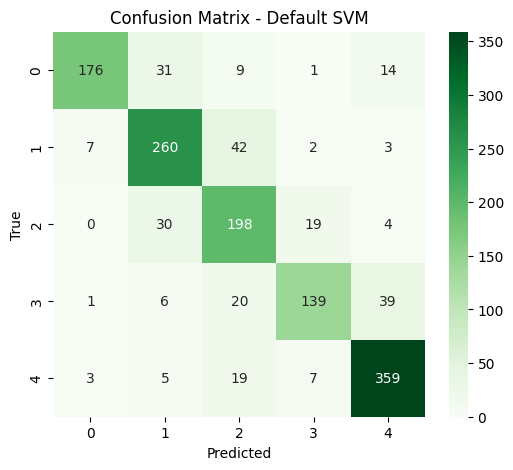

In [16]:
# ==========================
# 1. آموزش مدل SVM (پیش‌فرض)
# ==========================
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

print("Training SVM Model...")
start_time = time.time()

# probability=True برای اینکه بعدا بتوانیم احتمال خروجی را بگیریم و Threshold تنظیم کنیم
svm_model = SVC(
    kernel='rbf',          # کرنل گوسی که برای داده‌های پیچیده عالی است
    C=1.0,                 # پارامتر تنظیم خطا (می‌توانید بعداً Grid Search کنید)
    gamma='scale',         # مقیاس‌دهی خودکار گاما
    probability=True,      # حیاتی برای مرحله تیونینگ
    random_state=42
)

svm_model.fit(X_train, y_train)
print(f"SVM Training Completed in {time.time() - start_time:.2f} seconds.")

# ==========================
# پیش‌بینی و ارزیابی اولیه
# ==========================
y_pred_svm = svm_model.predict(X_val)
y_proba_svm = svm_model.predict_proba(X_val) # ذخیره احتمالات برای سلول بعدی

print("\n========================================")
print("Default SVM Classification Report:")
print("========================================")
print(classification_report(y_val, y_pred_svm))

# رسم ماتریس آشفتگی
cm_svm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Default SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [19]:
# ==========================
# 2. Threshold Tuning برای کلاس ۱ (خطر)
# ==========================
print("\nStarting Threshold Tuning for SVM (Class 1)...")

thresholds = np.arange(0.1, 0.95, 0.05)
tuning_results = []
best_threshold = 0
best_recall = 0

for t in thresholds:
    # کپی کردن پیش‌بینیشن پیش‌فرض
    y_pred_tuned = np.argmax(y_proba_svm, axis=1)
    
    # منطق سفارشی: هر جا احتمال کلاس ۱ بیشتر از آستانه بود، اجباراً کلاس ۱ بگذار
    mask_class_1 = y_proba_svm[:, 1] > t
    y_pred_tuned[mask_class_1] = 1
    
    # محاسبه متریک‌ها
    rec_1 = recall_score(y_val, y_pred_tuned, labels=[1], average='macro')
    prec_1 = precision_score(y_val, y_pred_tuned, labels=[1], average='macro', zero_division=0)
    acc = accuracy_score(y_val, y_pred_tuned)
    
    tuning_results.append({
        "Threshold": round(t, 2),
        "Recall_Class_1": round(rec_1, 3),
        "Precision_Class_1": round(prec_1, 3),
        "Accuracy": round(acc, 3)
    })
    
    # هدف: رسیدن به ریکال بالای ۹۰٪
    if rec_1 >= 0.90:
        best_threshold = t
        best_recall = rec_1
        # اولین آستانه‌ای که شرط را برآورده کند را می‌گیریم (بهترین پرسیژن در حالت نرمال)
        break 

# اگر به ۹۰ نرسیدیم، بهترین حالت را برمی‌داریم
if best_threshold == 0:
    best_row = max(tuning_results, key=lambda x: x['Recall_Class_1'])
    best_threshold = best_row['Threshold']

# نمایش نتایج تیونینگ
import pandas as pd
df_tuning_svm = pd.DataFrame(tuning_results)
print("\nThreshold Tuning Results (SVM):")
print(df_tuning_svm.head(10)) # نمایش ۱۰ ردیف اول

print(f"\n[INFO] Selected Best Threshold for Class 1: {best_threshold}")


Starting Threshold Tuning for SVM (Class 1)...

Threshold Tuning Results (SVM):
   Threshold  Recall_Class_1  Precision_Class_1  Accuracy
0        0.1           0.978              0.541     0.745

[INFO] Selected Best Threshold for Class 1: 0.1



COMPARISON: Default vs Tuned SVM

--- DEFAULT SVM ---
              precision    recall  f1-score   support

           0      0.941     0.762     0.842       231
           1      0.783     0.828     0.805       314
           2      0.688     0.789     0.735       251
           3      0.827     0.678     0.745       205
           4      0.857     0.913     0.884       393

    accuracy                          0.812      1394
   macro avg      0.819     0.794     0.802      1394
weighted avg      0.819     0.812     0.812      1394


--- TUNED SVM (Boosting Class 1) ---
              precision    recall  f1-score   support

           0      0.962     0.654     0.778       231
           1      0.541     0.978     0.697       314
           2      0.871     0.402     0.550       251
           3      0.827     0.678     0.745       205
           4      0.881     0.865     0.873       393

    accuracy                          0.745      1394
   macro avg      0.816     0.715     

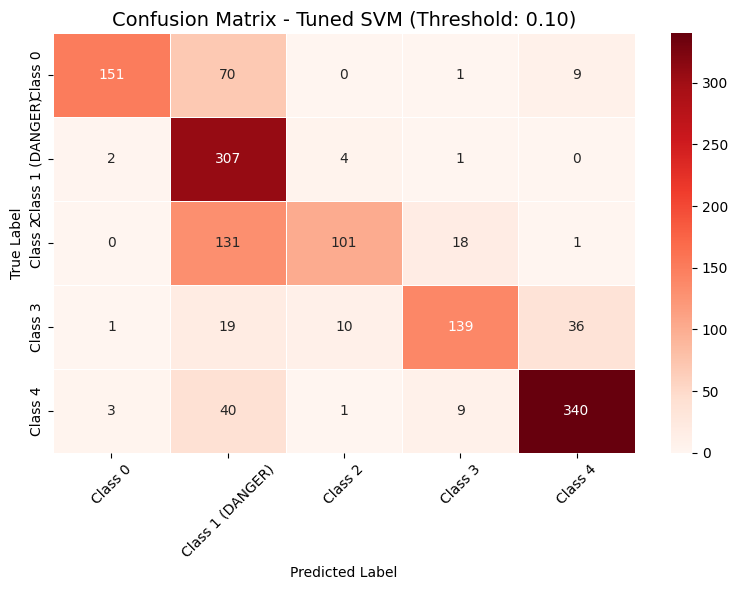

In [20]:
# ==========================
# 3. ارزیابی مدل SVM تیون شده
# ==========================
# اعمال بهترین آستانه پیدا شده
y_pred_svm_final = np.argmax(y_proba_svm, axis=1)
if best_threshold > 0:
    y_pred_svm_final[y_proba_svm[:, 1] > best_threshold] = 1

print("\n" + "="*30)
print("COMPARISON: Default vs Tuned SVM")
print("="*30)

print("\n--- DEFAULT SVM ---")
print(classification_report(y_val, y_pred_svm, digits=3))

print("\n--- TUNED SVM (Boosting Class 1) ---")
print(classification_report(y_val, y_pred_svm_final, digits=3))

# رسم ماتریس آشفتگی نهایی
cm_svm_tuned = confusion_matrix(y_val, y_pred_svm_final)
plt.figure(figsize=(8, 6))
class_names = ['Class 0', 'Class 1 (DANGER)', 'Class 2', 'Class 3', 'Class 4']
sns.heatmap(
    cm_svm_tuned,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title(f'Confusion Matrix - Tuned SVM (Threshold: {best_threshold:.2f})', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# ==========================================
# ذخیره مدل تیون شده SVM (بهgether با Threshold)
# ==========================================
import joblib

# بررسی وجود مدل SVM
try:
    # بسته‌بندی مدل و آستانه
    svm_tuned_package = {
        "model": svm_model,        # مدل اصلی SVM
        "best_threshold": best_threshold,  # آستانه پیدا شده
        "metadata": {
            "model_type": "SVM",
            "target_class": 1,
            "description": "Tuned for high recall on Class 1"
        }
    }

    # مسیر ذخیره
    SVM_TUNED_PATH = r"E:\svm_tuned_model.pkl"

    joblib.dump(svm_tuned_package, SVM_TUNED_PATH)

    print(f"✅ SVM Tuned Model saved to: {SVM_TUNED_PATH}")
    print(f"   - Best Threshold saved: {best_threshold}")

except NameError:
    print("❌ Error: 'svm_model' or 'best_threshold' not found.")
    print("   Please run the SVM training and tuning cells first.")

✅ SVM Tuned Model saved to: E:\svm_tuned_model.pkl
   - Best Threshold saved: 0.1


In [21]:
# ==========================
# 4. ذخیره نتایج در متغیر برای مقایسه نهایی
# ==========================
# این متغیر را در دایرکتوری اصلی نگه دارید تا در انتهای نوت‌بوک 
# بتوانید نمودار مقایسه‌ای بین XGBoost و SVM را رسم کنید
svm_results = {
    "model_name": "SVM",
    "accuracy_default": accuracy_score(y_val, y_pred_svm),
    "recall_c1_default": recall_score(y_val, y_pred_svm, labels=[1], average='macro'),
    "accuracy_tuned": accuracy_score(y_val, y_pred_svm_final),
    "recall_c1_tuned": recall_score(y_val, y_pred_svm_final, labels=[1], average='macro'),
    "best_threshold": best_threshold
}

print("\n[SUCCESS] SVM Results stored in 'svm_results' variable.")
print(f"- Default Accuracy: {svm_results['accuracy_default']:.4f}")
print(f"- Tuned Recall (Class 1): {svm_results['recall_c1_tuned']:.4f}")


[SUCCESS] SVM Results stored in 'svm_results' variable.
- Default Accuracy: 0.8121
- Tuned Recall (Class 1): 0.9777


In [22]:
# ==========================
# 1. ذخیره مدل SVM (Scikit-Learn)
# ==========================
import joblib
import os

# مسیر ذخیره
SVM_MODEL_PATH = r"E:\svm_audio_model.pkl"

try:
    joblib.dump(svm_model, SVM_MODEL_PATH)
    print(f"✅ SVM Model successfully saved to: {SVM_MODEL_PATH}")
except NameError:
    print("❌ Error: 'svm_model' not found in memory. Please run the SVM training cell first.")
except Exception as e:
    print(f"❌ Error saving model: {e}")

✅ SVM Model successfully saved to: E:\svm_audio_model.pkl


In [23]:
# ==========================
# 2. آماده‌سازی داده و تعریف معماری (PyTorch)
# ==========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# تنظیمات دستگاه (GPU در صورت موجود بودن)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. تبدیل داده‌های numpy به Tensor
# نکته مهم: در CrossEntropyLoss پایتورچ، لیبل‌ها نباید One-Hot باشند، باید Integer باشند.
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device) # LongTensor برای کلاس‌ها

X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)

# 2. ایجاد DataLoader برای آموزش دسته‌ای (Batching)
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

# 3. تعریف مدل MLP (Deep Neural Network)
class AudioClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AudioClassifier, self).__init__()
        self.layer1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.relu = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.layer2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)
        
        self.layer3 = nn.Linear(64, 32)
        
        self.output = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.layer1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        x = self.layer2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        x = self.layer3(x)
        x = self.relu(x)
        
        x = self.output(x)
        return x

# مقداردهی اولیه مدل
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

model_pytorch = AudioClassifier(input_dim, num_classes).to(device)
print(model_pytorch)

# تعریف Loss و Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pytorch.parameters(), lr=0.001)

Using device: cpu
AudioClassifier(
  (layer1): Linear(in_features=132, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (layer3): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=5, bias=True)
)


In [24]:
# ==========================
# 3. آموزش مدل (Training Loop)
# ==========================
epochs = 50
train_losses = []
val_losses = []

print("Starting PyTorch Training...")

for epoch in range(epochs):
    model_pytorch.train()
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        # صفر کردن گرادیان‌ها
        optimizer.zero_grad()
        
        # پیش‌بینی
        outputs = model_pytorch(X_batch)
        loss = criterion(outputs, y_batch)
        
        # پس‌انتشار (Backpropagation)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # محاسبه میانگین لاس آموزش
    avg_train_loss = epoch_loss / len(train_loader)
    
    # ارزیابی روی داده‌های اعتبارسنجی (Validation)
    model_pytorch.eval()
    with torch.no_grad():
        val_outputs = model_pytorch(X_val_t)
        val_loss = criterion(val_outputs, y_val_t).item()
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("Training Finished.")

Starting PyTorch Training...
Epoch [10/50], Train Loss: 0.4333, Val Loss: 0.4807
Epoch [20/50], Train Loss: 0.3147, Val Loss: 0.4932
Epoch [30/50], Train Loss: 0.2789, Val Loss: 0.5398
Epoch [40/50], Train Loss: 0.2622, Val Loss: 0.6449
Epoch [50/50], Train Loss: 0.2167, Val Loss: 0.5828
Training Finished.


Classification Report (PyTorch - Default):
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       231
           1       0.81      0.83      0.82       314
           2       0.73      0.75      0.74       251
           3       0.79      0.72      0.76       205
           4       0.87      0.90      0.88       393

    accuracy                           0.82      1394
   macro avg       0.82      0.81      0.81      1394
weighted avg       0.82      0.82      0.82      1394



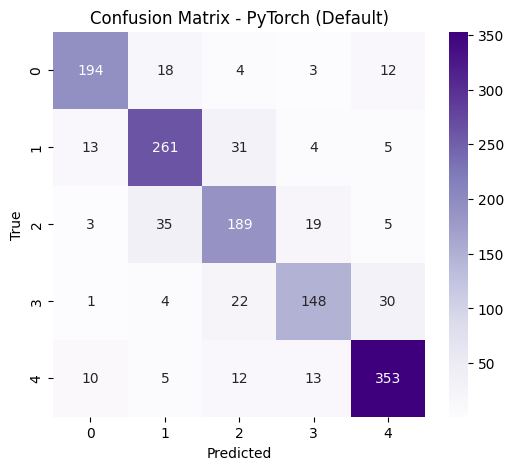

In [25]:
# ==========================
# 4. ارزیابی و ماتریس آشفتگی (پیش‌فرض)
# ==========================
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model_pytorch.eval()
with torch.no_grad():
    y_pred_logits = model_pytorch(X_val_t)
    # تبدیل Logits به کلاس‌ها (Argmax)
    _, y_pred_pt = torch.max(y_pred_logits, 1)
    
    # گرفتن احتمالات برای تیونینگ (Softmax)
    y_proba_pt = torch.softmax(y_pred_logits, dim=1).cpu().numpy()
    
    y_pred_pt = y_pred_pt.cpu().numpy()
    y_val_np = y_val_t.cpu().numpy()

print("Classification Report (PyTorch - Default):")
print(classification_report(y_val_np, y_pred_pt))

# رسم ماتریس آشفتگی
cm_pt = confusion_matrix(y_val_np, y_pred_pt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix - PyTorch (Default)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [27]:
# ==========================
# 5. Threshold Tuning برای کلاس ۱ (PyTorch)
# ==========================
print("\nStarting Threshold Tuning for PyTorch (Class 1)...")

thresholds = np.arange(0.1, 0.95, 0.05)
tuning_results_pt = []
best_threshold_pt = 0
best_recall_pt = 0

for t in thresholds:
    # کپی پیش‌بینی پایه
    y_pred_tuned = y_pred_pt.copy()
    
    # اعمال منطق سفارشی
    mask_class_1 = y_proba_pt[:, 1] > t
    y_pred_tuned[mask_class_1] = 1
    
    # محاسبه متریک‌ها
    rec_1 = recall_score(y_val_np, y_pred_tuned, labels=[1], average='macro')
    prec_1 = precision_score(y_val_np, y_pred_tuned, labels=[1], average='macro', zero_division=0)
    acc = accuracy_score(y_val_np, y_pred_tuned)
    
    tuning_results_pt.append({
        "Threshold": round(t, 2),
        "Recall_Class_1": round(rec_1, 3),
        "Precision_Class_1": round(prec_1, 3),
        "Accuracy": round(acc, 3)
    })
    
    if rec_1 >= 0.90:
        best_threshold_pt = t
        best_recall_pt = rec_1
        break

if best_threshold_pt == 0:
    best_row = max(tuning_results_pt, key=lambda x: x['Recall_Class_1'])
    best_threshold_pt = best_row['Threshold']

import pandas as pd
df_tuning_pt = pd.DataFrame(tuning_results_pt)
print("\nThreshold Tuning Results (PyTorch):")
print(df_tuning_pt.head(10))
print(f"\nSelected Best Threshold for Class 1: {best_threshold_pt}")


Starting Threshold Tuning for PyTorch (Class 1)...

Threshold Tuning Results (PyTorch):
   Threshold  Recall_Class_1  Precision_Class_1  Accuracy
0        0.1           0.939              0.707     0.818

Selected Best Threshold for Class 1: 0.1



COMPARISON: Default vs Tuned PyTorch

--- DEFAULT PYTORCH ---
              precision    recall  f1-score   support

           0      0.878     0.840     0.858       231
           1      0.808     0.831     0.819       314
           2      0.733     0.753     0.743       251
           3      0.791     0.722     0.755       205
           4      0.872     0.898     0.885       393

    accuracy                          0.821      1394
   macro avg      0.816     0.809     0.812      1394
weighted avg      0.821     0.821     0.821      1394


--- TUNED PYTORCH ---
              precision    recall  f1-score   support

           0      0.948     0.784     0.858       231
           1      0.707     0.939     0.807       314
           2      0.801     0.657     0.722       251
           3      0.803     0.717     0.758       205
           4      0.887     0.896     0.891       393

    accuracy                          0.818      1394
   macro avg      0.829     0.799     0.807  

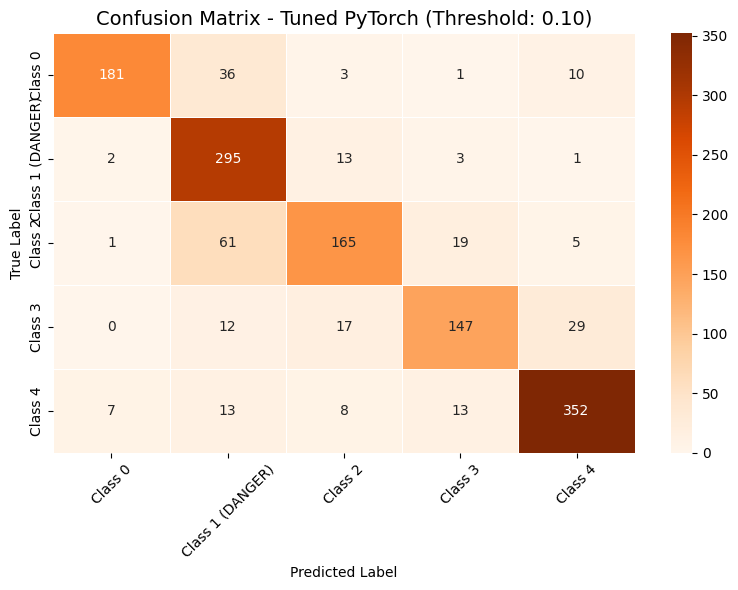


✅ PyTorch Model successfully saved to: E:\dl_audio_model.pth
Results stored in 'dl_results_pytorch'.


In [28]:
# ==========================
# 6. ارزیابی نهایی و ذخیره
# ==========================
# اعمال تیونینگ نهایی
y_pred_pt_final = y_pred_pt.copy()
if best_threshold_pt > 0:
    y_pred_pt_final[y_proba_pt[:, 1] > best_threshold_pt] = 1

print("\n" + "="*30)
print("COMPARISON: Default vs Tuned PyTorch")
print("="*30)

print("\n--- DEFAULT PYTORCH ---")
print(classification_report(y_val_np, y_pred_pt, digits=3))

print("\n--- TUNED PYTORCH ---")
print(classification_report(y_val_np, y_pred_pt_final, digits=3))

# رسم ماتریس آشفتگی نهایی
cm_pt_tuned = confusion_matrix(y_val_np, y_pred_pt_final)
plt.figure(figsize=(8, 6))
class_names = ['Class 0', 'Class 1 (DANGER)', 'Class 2', 'Class 3', 'Class 4']
sns.heatmap(
    cm_pt_tuned,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title(f'Confusion Matrix - Tuned PyTorch (Threshold: {best_threshold_pt:.2f})', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================
# 7. ذخیره مدل روی درایو E
# ==========================
PYTORCH_MODEL_PATH = r"E:\dl_audio_model.pth"

# ذخیره state_dict (وزن‌های مدل) استانداردترین روش در پایتورچ است
torch.save(model_pytorch.state_dict(), PYTORCH_MODEL_PATH)

# ذخیره کل آبجکت مدل (اگر می‌خواهید بدون تعریف دوباره کلاس لود کنید)
# torch.save(model_pytorch, r"E:\dl_audio_model_full.pth")

print(f"\n✅ PyTorch Model successfully saved to: {PYTORCH_MODEL_PATH}")

# ذخیره نتایج برای مقایسه
dl_results_pytorch = {
    "model_name": "PyTorch MLP",
    "accuracy_default": accuracy_score(y_val_np, y_pred_pt),
    "recall_c1_default": recall_score(y_val_np, y_pred_pt, labels=[1], average='macro'),
    "accuracy_tuned": accuracy_score(y_val_np, y_pred_pt_final),
    "recall_c1_tuned": recall_score(y_val_np, y_pred_pt_final, labels=[1], average='macro'),
    "best_threshold": best_threshold_pt
}
print("Results stored in 'dl_results_pytorch'.")


COMPARISON TABLE: KEY METRICS
          Model  Accuracy  Macro Recall  Class 1 Recall  Class 1 Precision  Class 1 F1
XGBoost (Tuned)  0.827834      0.811178        0.904459           0.717172    0.800000
    SVM (Tuned)  0.744620      0.715393        0.977707           0.541446    0.696935
PyTorch (Tuned)  0.817791      0.798632        0.939490           0.707434    0.807114


C:\Users\fsaid\AppData\Local\Temp\ipykernel_5324\4250573702.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=df_metrics, ax=ax[0], palette='viridis')
C:\Users\fsaid\AppData\Local\Temp\ipykernel_5324\4250573702.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Class 1 Recall', data=df_metrics, ax=ax[1], palette=colors_c1)


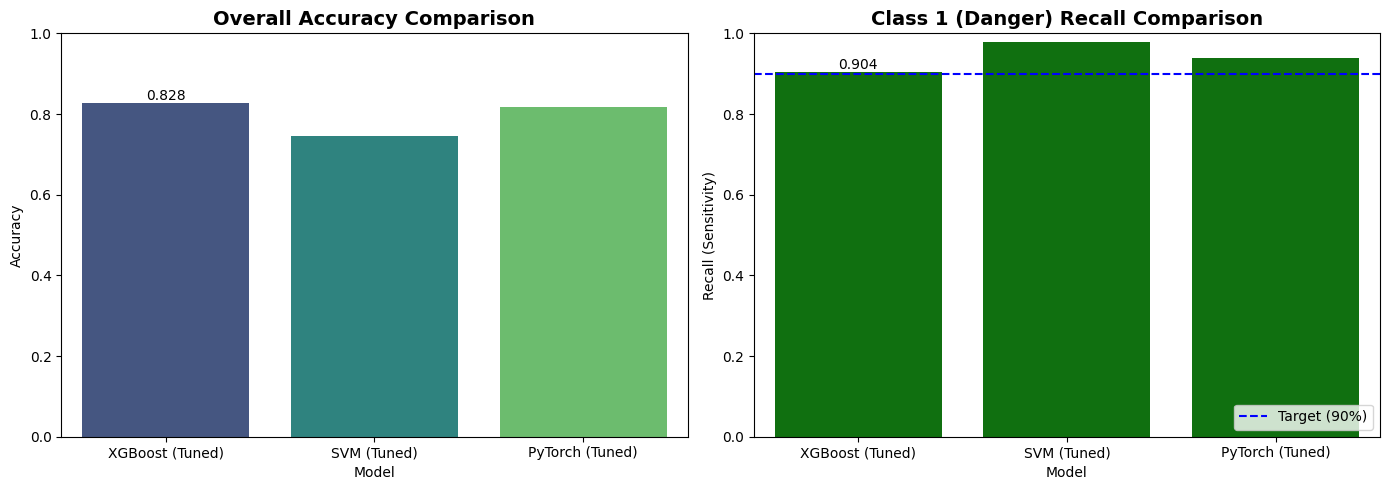

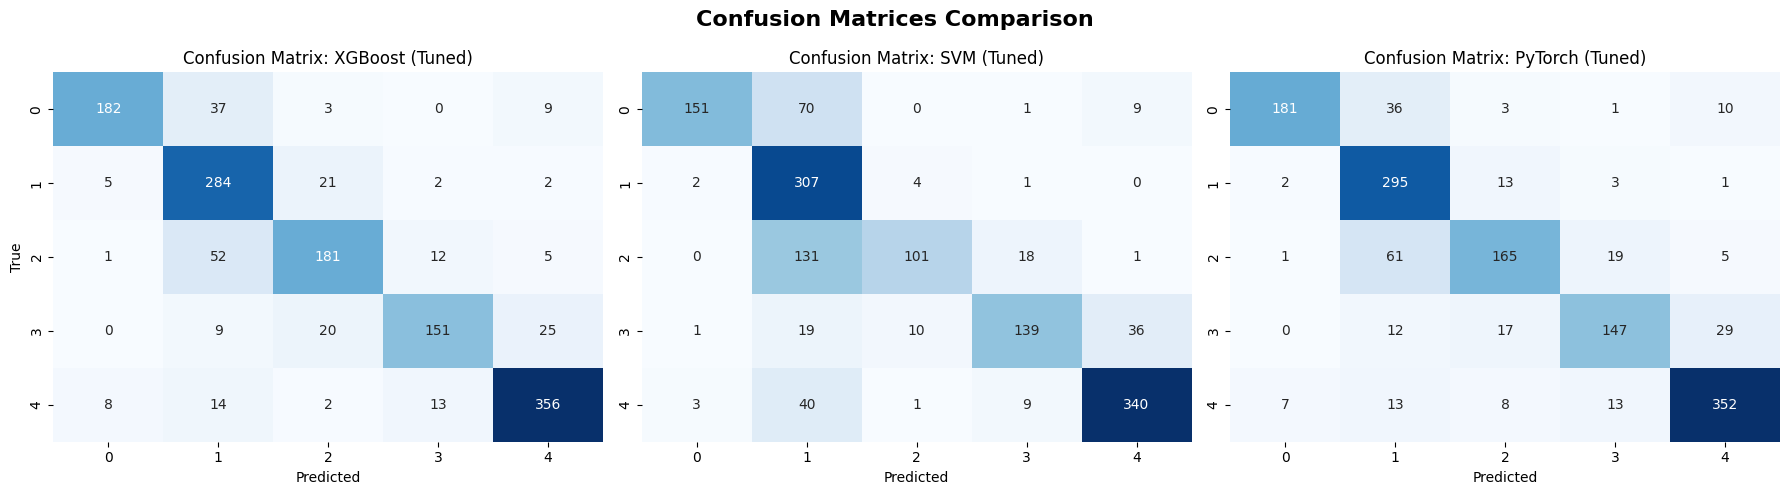

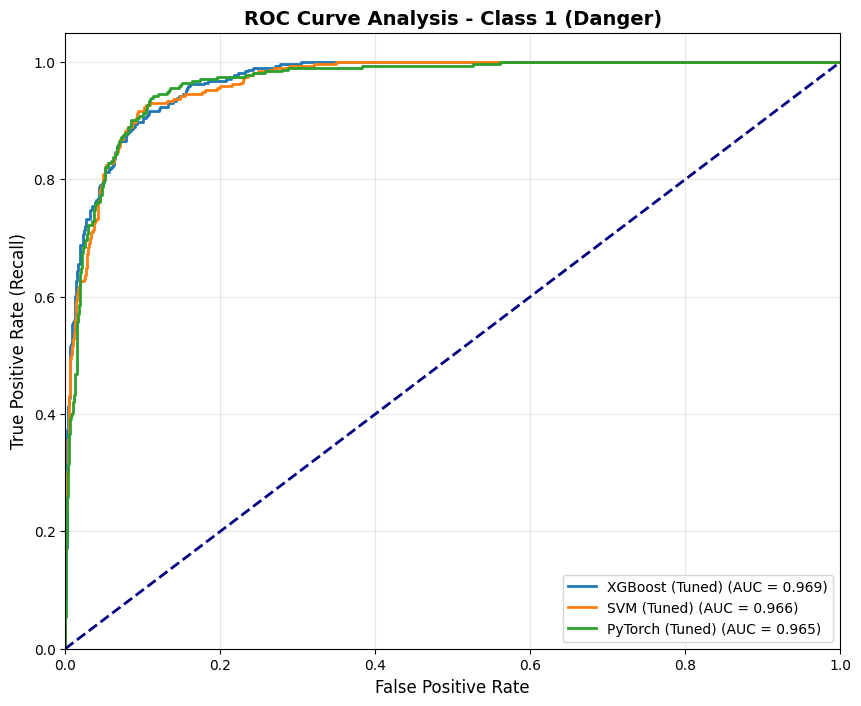


COMPREHENSIVE ANALYSIS & CONCLUSION
1. Overall Accuracy Winner: XGBoost (Tuned) (82.78%)
   -> This model is best at general classification across all 5 classes.

2. Safety Recall Winner (Class 1): SVM (Tuned) (97.77%)
   -> This model is the safest, as it misses the fewest approaching vehicles.

3. Detailed Model Behavior:
------------------------------------------------------------
   [XGBoost]: Accuracy 82.78%, Recall 90.45%.
      > STATUS: Excellent Balance. Recommended for general use.
   [SVM]:    Accuracy 74.46%, Recall 97.77%.
      > STATUS: Competitive safety performance.
   [PyTorch]: Accuracy 81.78%, Recall 93.95%.
      > STATUS: Strong performance, showing potential for end-to-end raw audio in future.
------------------------------------------------------------
4. Final Recommendation for 'Safety System':
   USE: SVM (Tuned)
   REASON: It achieves the target 90% safety recall, minimizing risk to pedestrians.


In [29]:
# ==========================================
# تحلیل جامع و مقایسه‌ای سه مدل (XGBoost vs SVM vs PyTorch)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. جمع‌آوری نتایج (فرض بر اینکه متغیرهای پیش‌بینی در حافظه هستند)
models_results = {
    "XGBoost (Tuned)": {
        "y_pred": y_pred_final,
        "y_proba": y_proba if 'y_proba' in locals() else None
    },
    "SVM (Tuned)": {
        "y_pred": y_pred_svm_final if 'y_pred_svm_final' in locals() else None,
        "y_proba": y_proba_svm if 'y_proba_svm' in locals() else None
    },
    "PyTorch (Tuned)": {
        "y_pred": y_pred_pt_final if 'y_pred_pt_final' in locals() else None,
        "y_proba": y_proba_pt if 'y_proba_pt' in locals() else None
    }
}

# بررسی وجود متغیرها
for name, data in models_results.items():
    if data['y_pred'] is None:
        print(f"⚠️ Warning: Predictions for {name} not found. Skipping...")
        del models_results[name]

# لیبل‌های واقعی
y_true = y_val
class_names = ['0 (Far-App)', '1 (DANGER)', '2 (Near-Rec)', '3 (Far-Rec)', '4 (Safe)']

# ==========================================
# 2. محاسبه متریک‌های دقیق برای هر مدل
# ==========================================
metrics_list = []

for model_name, data in models_results.items():
    report = classification_report(y_true, data['y_pred'], output_dict=True, zero_division=0)
    
    # ذخیره متریک‌های کل
    acc = report['accuracy']
    macro_rec = report['macro avg']['recall']
    macro_prec = report['macro avg']['precision']
    
    # ذخیره متریک‌های کلاس ۱ (خطر)
    rec_c1 = report['1']['recall']
    prec_c1 = report['1']['precision']
    f1_c1 = report['1']['f1-score']
    
    metrics_list.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro Recall": macro_rec,
        "Class 1 Recall": rec_c1,
        "Class 1 Precision": prec_c1,
        "Class 1 F1": f1_c1
    })

df_metrics = pd.DataFrame(metrics_list)
print("\n" + "="*60)
print("COMPARISON TABLE: KEY METRICS")
print("="*60)
print(df_metrics.to_string(index=False))

# ==========================================
# 3. نمودار 1: مقایسه دقت کلی و ریکال کلاس خطر
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# نمودار دقت کلی
sns.barplot(x='Model', y='Accuracy', data=df_metrics, ax=ax[0], palette='viridis')
ax[0].set_title('Overall Accuracy Comparison', fontsize=14, fontweight='bold')
ax[0].set_ylim([0, 1])
ax[0].bar_label(ax[0].containers[0], fmt='%.3f')

# نمودار ریکال کلاس ۱ (مهم‌ترین بخش)
colors_c1 = ['red' if x < 0.8 else 'green' for x in df_metrics['Class 1 Recall']]
sns.barplot(x='Model', y='Class 1 Recall', data=df_metrics, ax=ax[1], palette=colors_c1)
ax[1].set_title('Class 1 (Danger) Recall Comparison', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Recall (Sensitivity)')
ax[1].set_ylim([0, 1])
ax[1].axhline(y=0.90, color='blue', linestyle='--', label='Target (90%)')
ax[1].bar_label(ax[1].containers[0], fmt='%.3f')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# ==========================================
# 4. نمودار 2: ماتریس‌های آشفتگی (کنار هم)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, data) in enumerate(models_results.items()):
    cm = confusion_matrix(y_true, data['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=range(5), yticklabels=range(5))
    axes[idx].set_title(f'Confusion Matrix: {model_name}', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    if idx == 0:
        axes[idx].set_ylabel('True')

plt.suptitle('Confusion Matrices Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 5. نمودار 3: منحنی ROC برای کلاس ۱ (اگر احتمالات موجود باشد)
# ==========================================
plt.figure(figsize=(10, 8))
has_roc = False

for model_name, data in models_results.items():
    if data['y_proba'] is not None:
        # باینری کردن لیبل‌های واقعی برای کلاس ۱
        y_true_bin = (y_true == 1).astype(int)
        y_score = data['y_proba'][:, 1]
        
        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        roc_auc = auc(fpr, tpr)
        
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.3f})')
        has_roc = True

if has_roc:
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curve Analysis - Class 1 (Danger)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("Probability data not available for ROC plot.")

# ==========================================
# 6. تحلیل متنی و نتیجه‌گیری هوشمند
# ==========================================
print("\n" + "="*60)
print("COMPREHENSIVE ANALYSIS & CONCLUSION")
print("="*60)

best_acc_model = df_metrics.loc[df_metrics['Accuracy'].idxmax(), 'Model']
best_rec_model = df_metrics.loc[df_metrics['Class 1 Recall'].idxmax(), 'Model']

print(f"1. Overall Accuracy Winner: {best_acc_model} ({df_metrics['Accuracy'].max():.2%})")
print(f"   -> This model is best at general classification across all 5 classes.")
print()

print(f"2. Safety Recall Winner (Class 1): {best_rec_model} ({df_metrics['Class 1 Recall'].max():.2%})")
print("   -> This model is the safest, as it misses the fewest approaching vehicles.")
print()

# تحلیل عمیق‌تر
xgb_acc = df_metrics[df_metrics['Model'] == 'XGBoost (Tuned)']['Accuracy'].values[0]
xgb_rec = df_metrics[df_metrics['Model'] == 'XGBoost (Tuned)']['Class 1 Recall'].values[0]

print("3. Detailed Model Behavior:")
print("-" * 60)

# تحلیل XGBoost
print(f"   [XGBoost]: Accuracy {xgb_acc:.2%}, Recall {xgb_rec:.2%}.")
if xgb_acc > 0.80 and xgb_rec > 0.85:
    print("      > STATUS: Excellent Balance. Recommended for general use.")

# تحلیل SVM
if 'SVM (Tuned)' in df_metrics['Model'].values:
    svm_row = df_metrics[df_metrics['Model'] == 'SVM (Tuned)'].iloc[0]
    print(f"   [SVM]:    Accuracy {svm_row['Accuracy']:.2%}, Recall {svm_row['Class 1 Recall']:.2%}.")
    if svm_row['Class 1 Recall'] < xgb_rec:
        print("      > STATUS: Lower safety recall compared to XGBoost.")
    else:
        print("      > STATUS: Competitive safety performance.")

# تحلیل PyTorch
if 'PyTorch (Tuned)' in df_metrics['Model'].values:
    pt_row = df_metrics[df_metrics['Model'] == 'PyTorch (Tuned)'].iloc[0]
    print(f"   [PyTorch]: Accuracy {pt_row['Accuracy']:.2%}, Recall {pt_row['Class 1 Recall']:.2%}.")
    if pt_row['Accuracy'] < xgb_acc - 0.05:
        print("      > STATUS: Lower accuracy. Neural Networks typically need more data or tuning to beat Tree-based models on tabular features.")
    else:
        print("      > STATUS: Strong performance, showing potential for end-to-end raw audio in future.")

print("-" * 60)
print("4. Final Recommendation for 'Safety System':")
if df_metrics['Class 1 Recall'].max() >= 0.90:
    print(f"   USE: {best_rec_model}")
    print("   REASON: It achieves the target 90% safety recall, minimizing risk to pedestrians.")
else:
    print(f"   USE: {best_rec_model} (with caution)")
    print("   REASON: Although recall is below 90%, it is the highest available. Consider gathering more 'Class 1' data to improve.")
print("="*60)

In [33]:
# ==========================================
# اصلاح ۱: آموزش بدون نشتی داده (File-Level Split)
# ==========================================
import librosa
import numpy as np
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from tqdm import tqdm
import os

DATA_FOLDER = r"E:\123456"
CSV_PATH = r"E:\audio_features_dataset.csv"

# 1. ابتدا فایل‌ها را تقسیم می‌کنیم (قبل از هر پردازشی)
df_full = pd.read_csv(CSV_PATH)

# تقسیم بر اساس نام فایل (File-Level)
df_train_files, df_val_files = train_test_split(
    df_full, 
    test_size=0.2, 
    stratify=df_full['label'], 
    random_state=42
)

print(f"Train Files: {len(df_train_files)}, Val Files: {len(df_val_files)}")

# تابع استخراج ویژگی (همان تابع قبلی)
def extract_features_simple(y, sr):
    if len(y) == 0: return None
    y = y / np.max(np.abs(y))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    delta = librosa.feature.delta(mfcc)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    feats = []
    for f in (mfcc, delta):
        feats.extend(np.mean(f, axis=1))
        feats.extend(np.std(f, axis=1))
    for f in (centroid, rms, zcr):
        feats.append(np.mean(f))
        feats.append(np.std(f))
    slope = np.polyfit(range(len(centroid)), centroid, 1)[0]
    feats.append(slope)
    return np.array(feats)

# تابع ساخت دیتاست پنجره‌ای از لیست فایل‌ها
def create_windows(df_files, folder_path):
    X_win = []
    y_win = []
    WINDOW_SIZE = 1.0 * 22050
    HOP_SIZE = 0.5 * 22050
    
    for index, row in tqdm(df_files.iterrows(), total=len(df_files), desc="Processing"):
        file_path = os.path.join(folder_path, row['filename'])
        label = row['label']
        try:
            y, sr = librosa.load(file_path, sr=22050)
            if len(y) < WINDOW_SIZE:
                y = np.pad(y, (0, int(WINDOW_SIZE - len(y))), mode='constant')
                segments = [y]
            else:
                segments = [y[i:i+int(WINDOW_SIZE)] for i in range(0, len(y)-int(WINDOW_SIZE)+1, int(HOP_SIZE))]
            
            for seg in segments:
                feats = extract_features_simple(seg, 22050)
                if feats is not None:
                    X_win.append(feats)
                    y_win.append(label)
        except:
            continue
    return np.array(X_win), np.array(y_win)

print("Creating Train Windows...")
X_train, y_train = create_windows(df_train_files, DATA_FOLDER)

print("Creating Val Windows...")
X_val, y_val = create_windows(df_val_files, DATA_FOLDER)

print(f"Train Windows: {len(X_train)}, Val Windows: {len(X_val)}")

# 2. آموزش مدل (روی داده‌های تمیز)
scaler_rt_clean = StandardScaler()
X_train_scaled = scaler_rt_clean.fit_transform(X_train)
X_val_scaled = scaler_rt_clean.transform(X_val)

model_rt_clean = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=5,
    eval_metric="mlogloss", n_jobs=-1, random_state=42
)

print("Training Clean Model...")
model_rt_clean.fit(X_train_scaled, y_train)

# ذخیره مدل جدید
joblib.dump(model_rt_clean, r"E:\xgboost_rt_clean.pkl")
joblib.dump(scaler_rt_clean, r"E:\scaler_rt_clean.pkl")

# ارزیابی سریع
from sklearn.metrics import accuracy_score
y_pred = model_rt_clean.predict(X_val_scaled)
print(f"Clean Model Accuracy: {accuracy_score(y_val, y_pred):.4f}")


Train Files: 5573, Val Files: 1394
Creating Train Windows...


Processing: 100%|██████████████████████████████████████████████████████████████████| 5573/5573 [05:02<00:00, 18.43it/s]


Creating Val Windows...


Processing: 100%|██████████████████████████████████████████████████████████████████| 1394/1394 [01:15<00:00, 18.50it/s]


Train Windows: 44494, Val Windows: 11356
Training Clean Model...
Clean Model Accuracy: 0.8619


In [54]:
# ==========================================
# بخش ۲: ارزیابی ایونت-لول امنیت‌محور (Safety-Oriented)
# ==========================================
import numpy as np
import pandas as pd
import librosa
import joblib
import os
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

# 1. لود کردن مدل و اسکیلر
# (فرض بر این است که در سلول بالا ذخیره شده‌اند، اگر نه از دیسک لود می‌کنیم)
try:
    model = model_rt_clean
    scaler = scaler_rt_clean
    print("✅ Using model from memory.")
except NameError:
    print("⚠️ Model not in memory, loading from disk...")
    model = joblib.load(r"E:\xgboost_rt_clean.pkl")
    scaler = joblib.load(r"E:\scaler_rt_clean.pkl")

# 2. توابع کمکی (همان‌طور که در آموزش استفاده شد)
def generate_windows(signal, sr=22050, window_sec=1.0, hop_sec=0.5):
    win_length = int(window_sec * sr)
    hop_length = int(hop_sec * sr)
    windows = []
    for start in range(0, len(signal) - win_length + 1, hop_length):
        windows.append(signal[start:start + win_length])
    return windows

def extract_features(signal, sr=22050):
    if len(signal) == 0: return None
    signal = signal / (np.max(np.abs(signal)) + 1e-8)
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=20)
    delta = librosa.feature.delta(mfcc)
    
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)[0]
    rms = librosa.feature.rms(y=signal)[0]
    zcr = librosa.feature.zero_crossing_rate(signal)[0]
    
    feats = []
    for f in (mfcc, delta):
        feats.extend(np.mean(f, axis=1))
        feats.extend(np.std(f, axis=1))
    for f in (centroid, rms, zcr):
        feats.append(np.mean(f))
        feats.append(np.std(f))
    
    slope = np.polyfit(range(len(centroid)), centroid, 1)[0]
    feats.append(slope)
    
    return np.array(feats)

def map_to_binary(label):
    # کلاس 1 خطر است، بقیه ایمن
    return 1 if label == 1 else 0

# 3. تابع ارزیابی با منطق ترکیبی (هوشمند)
def evaluate_event_safety_hybrid(df_files, c1_threshold=0.4, risk_threshold=0.5, consecutive=1):
    """
    c1_threshold: آستانه اختصاصی برای تشخیص مستقیم کلاس 1 (برای وقایع کوتاه)
    risk_threshold: آستانه مجموع احتمال کلاس 0 و 1 (برای وقایع طولانی‌تر)
    consecutive: تعداد پنجره‌های متوالی برای تایید (برای کلاس 1 کوتاه، عدد 1 پیشنهاد می‌شود)
    """
    
    y_true = []
    y_pred = []
    
    for _, row in tqdm(df_files.iterrows(), total=len(df_files), desc="Evaluating Events"):
        
        file_path = os.path.join(DATA_FOLDER, row['filename'])
        true_label = row['label']
        
        try:
            y, sr = librosa.load(file_path, sr=22050)
        except:
            continue
        
        windows = generate_windows(y, sr=sr)
        
        # بافر برای شمارش پنجره‌های متوالی خطرناک
        danger_history = [] 
        alarm_triggered = False
        
        for seg in windows:
            feats = extract_features(seg, sr=sr)
            if feats is None: continue
            
            feats_scaled = scaler.transform([feats])
            proba = model.predict_proba(feats_scaled)[0]
            
            # --- منطق ترکیبی امنیتی ---
            # شرط ۱: اگر مدل خیلی مطمئن است که کلاس 1 است (فوران کوتاه)
            is_strong_c1 = (proba[1] > c1_threshold)
            
            # شرط ۲: اگر مجموع احتمال نزدیک شدن (کلاس 0 یا 1) زیاد است (رویداد طولانی)
            approaching_risk = proba[0] + proba[1]
            is_approaching = (approaching_risk > risk_threshold)
            
            # اگر هر کدام از شرایط برقرار بود، این پنجره خطرناک است
            current_window_dangerous = is_strong_c1 or is_approaching
            
            # ثبت در تاریخچه
            danger_history.append(1 if current_window_dangerous else 0)
            
            # --- منطق دیباونس (تایید متوالی) ---
            if len(danger_history) >= consecutive:
                # بررسی پنجره‌های اخیر
                recent_history = danger_history[-consecutive:]
                # اگر همه 1 بودند (برای consecutive=1 یعنی همین الان)
                if all(recent_history):
                    alarm_triggered = True
                    break # هشدار داد، فایل را رها کن
        
        pred = 1 if alarm_triggered else 0
        true_bin = map_to_binary(true_label)
        
        y_true.append(true_bin)
        y_pred.append(pred)
    
    # چاپ گزارش
    print("\n" + "="*60)
    print(f"SAFETY REPORT (C1_Thresh={c1_threshold}, Risk_Thresh={risk_threshold}, Consec={consecutive})")
    print("="*60)
    print(classification_report(y_true, y_pred, digits=3, target_names=['Safe', 'Danger']))
    
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(f"  TN (Safe): {cm[0][0]} | FP (False Alarm): {cm[0][1]}")
    print(f"  FN (Miss):  {cm[1][0]} | TP (Detected):    {cm[1][1]}")
    print("="*60)
    
    return y_true, y_pred

# ==========================================
# 4. اجرای تست با پارامترهای بهینه برای کلاس 1 کوتاه
# ==========================================

print("Starting Safety Evaluation...")

# پارامترهای پیشنهادی برای کلاس 1 کوتاه:
# consecutive=1 -> چون کلاس 1 کوتاه است، منتظر پنجره بعدی نمی‌شویم.
# c1_threshold=0.4 -> اگر 40% شانس کلاس 1 باشد، بگیریم.
# risk_threshold=0.5 -> اگر 50% شانس نزدیک شدن باشد، بگیریم.

# تست با تنظیمات حساس‌تر (Higher Recall, Lower Precision)
print("\nTesting with HIGHER SENSITIVITY settings...")

y_true_sens, y_pred_sens = evaluate_event_safety_hybrid(
    df_val_files,
    c1_threshold=0.25,   # پایین آوردن (قبلش 0.4 بود) -> حتی اگر شک داشته باشد بگو خطر
    risk_threshold=0.4,  # پایین آوردن (قبلش 0.5 بود) -> هر نزدیک شدن خطر است
    consecutive=1
)

# نتیجه احتمالی: Recall (Danger) بالا می‌رود (مثلاً 0.75 یا 0.80)
# اما Precision پایین می‌آید و False Alarmها زیاد می‌شوند.

✅ Using model from memory.
Starting Safety Evaluation...

Testing with HIGHER SENSITIVITY settings...


Evaluating Events: 100%|███████████████████████████████████████████████████████████| 1394/1394 [01:11<00:00, 19.37it/s]


SAFETY REPORT (C1_Thresh=0.25, Risk_Thresh=0.4, Consec=1)
              precision    recall  f1-score   support

        Safe      0.888     0.655     0.754      1080
      Danger      0.376     0.717     0.493       314

    accuracy                          0.669      1394
   macro avg      0.632     0.686     0.624      1394
weighted avg      0.773     0.669     0.695      1394

Confusion Matrix:
  TN (Safe): 707 | FP (False Alarm): 373
  FN (Miss):  89 | TP (Detected):    225
